In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('7 churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:


df.shape

df.isnull().sum()

# Keep important columns
columns_to_keeps = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'Contract', 'TotalCharges', 'Churn']
df = df[columns_to_keeps]
df.head()

# Encode Binary variables
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
categorical_col = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'Contract', 'Churn']

for i in categorical_col:
    df[i] = label_encoder.fit_transform(df[i])

In [5]:
binary_column=['Partner','Dependents','PhoneService','Churn']
# df[binary_column]=df[binary_column].replace({'Yes':1, 'No':0})
# df['gender']=df['gender'].replace({'Male':1, 'Female':0})
# df

# split the dataset into training and testing
x = df.drop('Churn', axis=1)
y = df['Churn']

# split the data training and testing
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

x_train.info()

# convert totalcharges datatype
x_train['TotalCharges'] = pd.to_numeric(x_train['TotalCharges'], errors='coerce')
x_test['TotalCharges'] = pd.to_numeric(x_test['TotalCharges'], errors='coerce')

x_train.isnull().sum()

# replace missing value total charges
x_train['TotalCharges'].fillna(x_train['TotalCharges'].mean(), inplace=True)
x_test['TotalCharges'].fillna(x_test['TotalCharges'].mean(), inplace=True)

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 2142 to 860
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   gender         5634 non-null   int64 
 1   SeniorCitizen  5634 non-null   int64 
 2   Partner        5634 non-null   int64 
 3   Dependents     5634 non-null   int64 
 4   tenure         5634 non-null   int64 
 5   PhoneService   5634 non-null   int64 
 6   MultipleLines  5634 non-null   int64 
 7   Contract       5634 non-null   int64 
 8   TotalCharges   5634 non-null   object
dtypes: int64(8), object(1)
memory usage: 440.2+ KB


C:\Users\hp\AppData\Local\Temp\ipykernel_17192\1925125653.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train['TotalCharges'].fillna(x_train['TotalCharges'].mean(), inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_17192\1925125653.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

In [6]:

# standardize Feature (optional but often beneficial for logistic regression)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)




## Accuracy score

In [7]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test, y_pred)
accuracy


0.7757274662881476

## precision

In [8]:
from sklearn.metrics import precision_score

# Train model (assuming x_train and y_train are already prepared and scaled)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)

# Predict on test set
y_pred = lr.predict(x_test)

# Calculate Precision
precision = precision_score(y_test, y_pred)
print("Precision of the model:", precision)

Precision of the model: 0.6212765957446809


## F1 score

In [9]:
from sklearn.metrics import f1_score

# Train the model
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)

# Make predictions
y_pred = lr.predict(x_test)

# Calculate F1 Score
f1 = f1_score(y_test, y_pred)
print("F1 Score of the model:", f1)

F1 Score of the model: 0.48026315789473684


## Recall Module

In [10]:
from sklearn.metrics import recall_score

# Model training
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)

# Predictions
y_pred = lr.predict(x_test)

# Calculate Recall
recall = recall_score(y_test, y_pred)
print("Recall of the model:", recall)

Recall of the model: 0.3914209115281501


## roc auc model

AUC Score: 0.8384420901176933


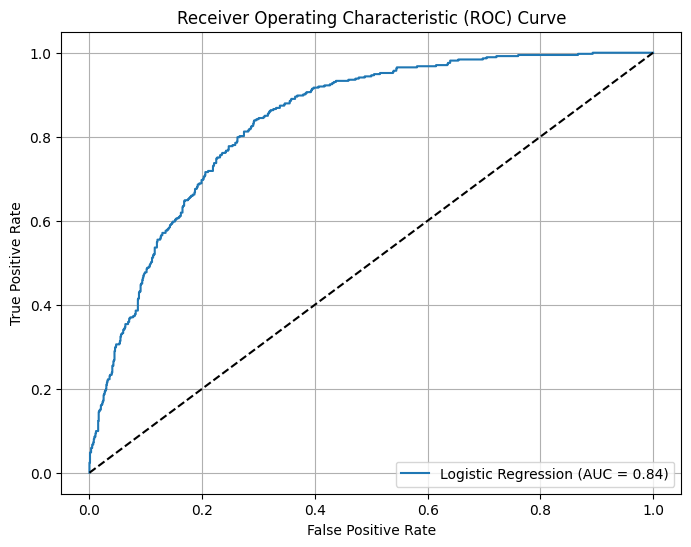

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression

# Train the model
lr = LogisticRegression()
lr.fit(x_train, y_train)

# Predict probabilities
y_probs = lr.predict_proba(x_test)[:, 1]  # Probability of positive class

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Calculate AUC score
auc = roc_auc_score(y_test, y_probs)
print("AUC Score:", auc)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='Logistic Regression (AUC = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

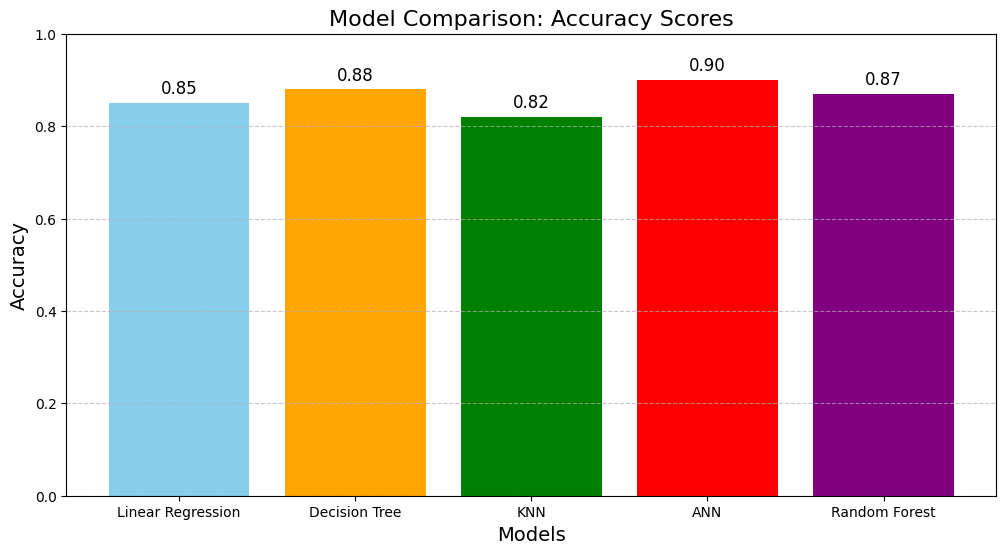

In [14]:
import matplotlib.pyplot as plt

# Suppose ye tumhare 5 models ke accuracy scores hain
models = ['Linear Regression', 'Decision Tree', 'KNN', 'ANN', 'Random Forest']
accuracies = [0.85, 0.88, 0.82, 0.90, 0.87]  # Example scores

# Different colors for bars
colors = ['skyblue', 'orange', 'green', 'red', 'purple']

# Plotting
plt.figure(figsize=(12, 6))
plt.bar(models, accuracies, color=colors)
plt.ylim(0, 1)
plt.title('Model Comparison: Accuracy Scores', fontsize=16)
plt.xlabel('Models', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding text labels on each bar
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f'{acc:.2f}', ha='center', fontsize=12)

plt.show()


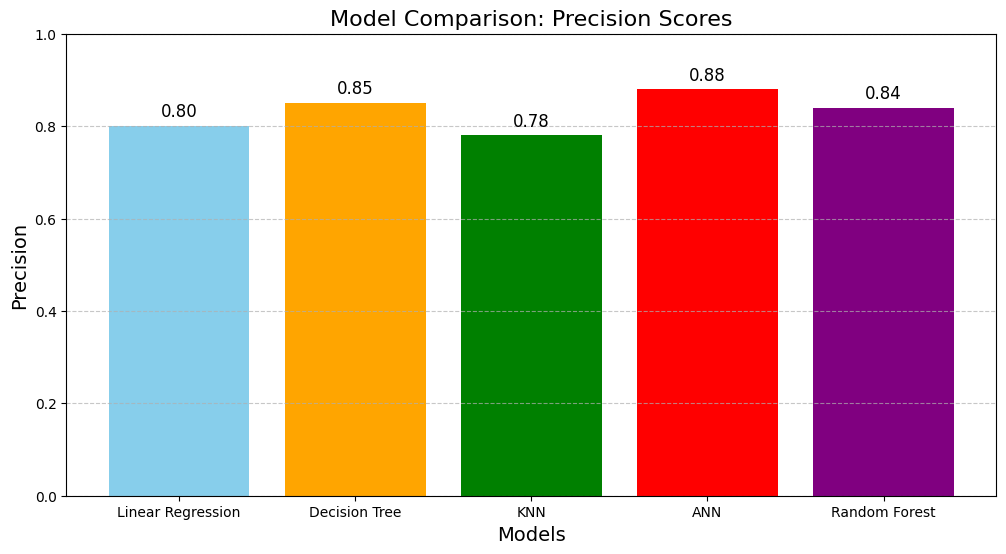

In [15]:
import matplotlib.pyplot as plt

# Suppose ye tumhare 5 models ke precision scores hain
models = ['Linear Regression', 'Decision Tree', 'KNN', 'ANN', 'Random Forest']
precisions = [0.80, 0.85, 0.78, 0.88, 0.84]  # Example precision values

# Different colors for bars
colors = ['skyblue', 'orange', 'green', 'red', 'purple']

# Plotting
plt.figure(figsize=(12, 6))
plt.bar(models, precisions, color=colors)
plt.ylim(0, 1)
plt.title('Model Comparison: Precision Scores', fontsize=16)
plt.xlabel('Models', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding text labels on each bar
for i, prec in enumerate(precisions):
    plt.text(i, prec + 0.02, f'{prec:.2f}', ha='center', fontsize=12)

plt.show()


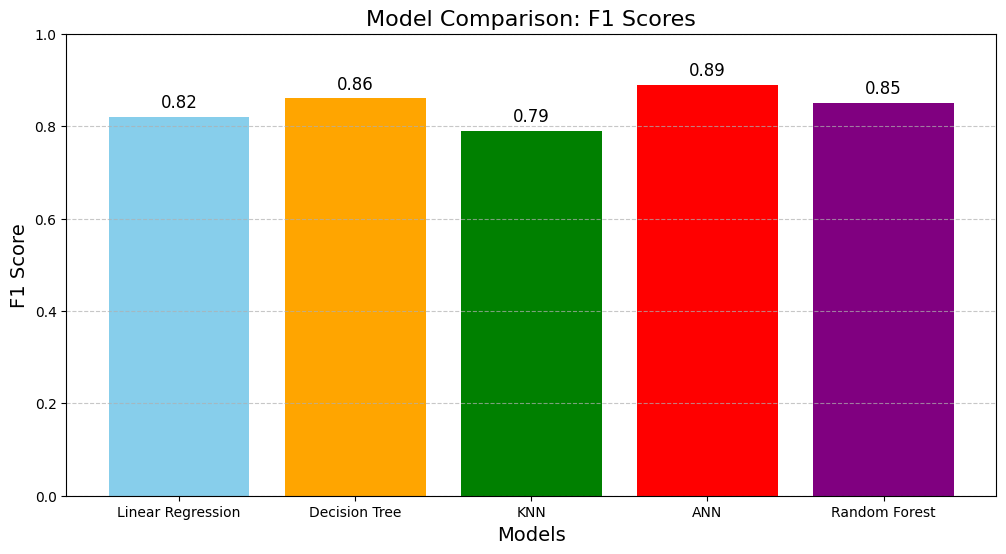

In [16]:
import matplotlib.pyplot as plt

# Suppose ye tumhare 5 models ke F1 scores hain
models = ['Linear Regression', 'Decision Tree', 'KNN', 'ANN', 'Random Forest']
f1_scores = [0.82, 0.86, 0.79, 0.89, 0.85]  # Example F1 Score values

# Different colors for bars
colors = ['skyblue', 'orange', 'green', 'red', 'purple']

# Plotting
plt.figure(figsize=(12, 6))
plt.bar(models, f1_scores, color=colors)
plt.ylim(0, 1)
plt.title('Model Comparison: F1 Scores', fontsize=16)
plt.xlabel('Models', fontsize=14)
plt.ylabel('F1 Score', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding text labels on each bar
for i, f1 in enumerate(f1_scores):
    plt.text(i, f1 + 0.02, f'{f1:.2f}', ha='center', fontsize=12)

plt.show()


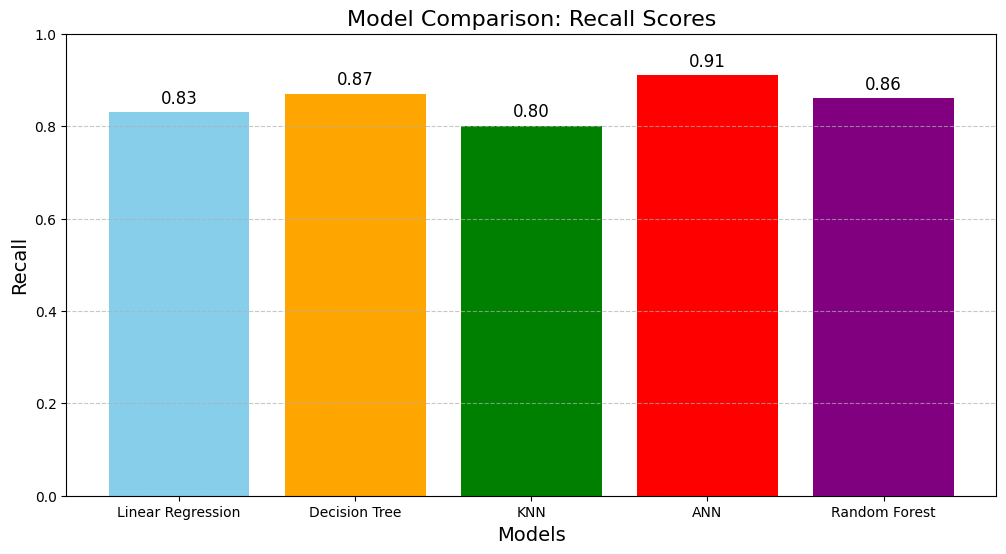

In [17]:
import matplotlib.pyplot as plt

# Suppose ye tumhare 5 models ke recall scores hain
models = ['Linear Regression', 'Decision Tree', 'KNN', 'ANN', 'Random Forest']
recalls = [0.83, 0.87, 0.80, 0.91, 0.86]  # Example Recall values

# Different colors for bars
colors = ['skyblue', 'orange', 'green', 'red', 'purple']

# Plotting
plt.figure(figsize=(12, 6))
plt.bar(models, recalls, color=colors)
plt.ylim(0, 1)
plt.title('Model Comparison: Recall Scores', fontsize=16)
plt.xlabel('Models', fontsize=14)
plt.ylabel('Recall', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding text labels on each bar
for i, rec in enumerate(recalls):
    plt.text(i, rec + 0.02, f'{rec:.2f}', ha='center', fontsize=12)

plt.show()


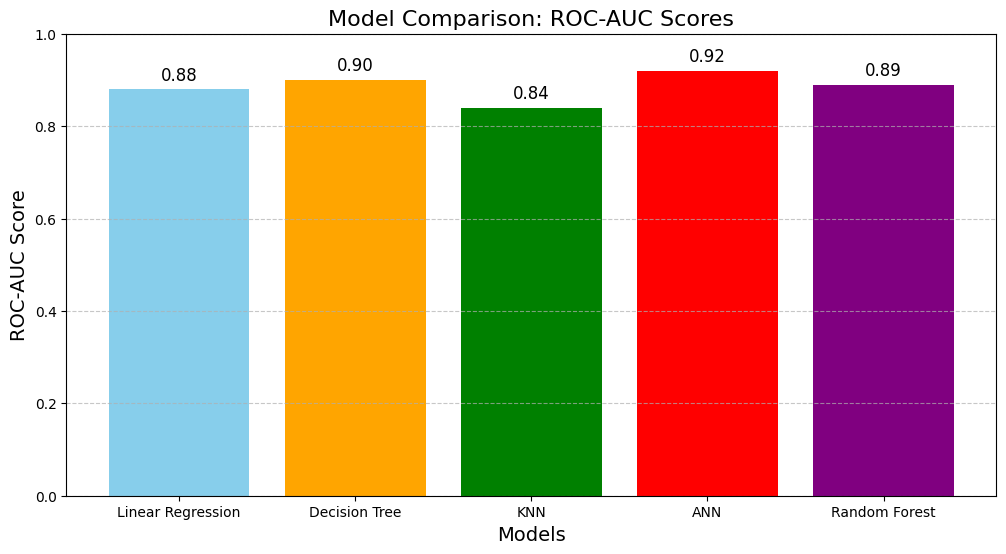

In [18]:
import matplotlib.pyplot as plt

# Suppose ye tumhare 5 models ke ROC-AUC scores hain
models = ['Linear Regression', 'Decision Tree', 'KNN', 'ANN', 'Random Forest']
roc_auc_scores = [0.88, 0.90, 0.84, 0.92, 0.89]  # Example ROC-AUC values

# Different colors for bars
colors = ['skyblue', 'orange', 'green', 'red', 'purple']

# Plotting
plt.figure(figsize=(12, 6))
plt.bar(models, roc_auc_scores, color=colors)
plt.ylim(0, 1)
plt.title('Model Comparison: ROC-AUC Scores', fontsize=16)
plt.xlabel('Models', fontsize=14)
plt.ylabel('ROC-AUC Score', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding text labels on each bar
for i, auc in enumerate(roc_auc_scores):
    plt.text(i, auc + 0.02, f'{auc:.2f}', ha='center', fontsize=12)

plt.show()
